# xgb_3class_xfn5d_simple — Performance & SHAP Analysis

**Model**: `xgb_3class_xfn5d_simple` — XGBoost multiclass signal detector  
**Target**: 5-day excess return of TD vs XFN sector ETF (`target_excess_xfn_5d`)  
**Labels**: Outperform (+1) / Neutral (0) / Underperform (−1), band ±0.30%  
**Features**: 15 (same raw, explainable-only set as `lgbm_3class_xfn5d_simple`)  
**Validation**: 7-fold expanding-window walk-forward (stride-5 offset averaging)

This notebook:
1. Loads the tuned XGBoost artifact and verifies it
2. Engineers the 5 notebook-only features on top of `load_dataset()`
3. Re-runs 7-fold walk-forward evaluation (same protocol as LGBM performance notebook)
4. Reports per-fold and aggregate performance (DirAcc, ASA, coverage)
5. SHAP global importance + heatmap + per-fold beeswarm
6. Side-by-side comparison: XGB 15f vs LGBM 15f (same 7 folds, same protocol)

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from IPython.display import display

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path('').resolve()
ROOT = NOTEBOOK_DIR.parents[1]
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments_archive'

for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'
print(f'ROOT: {ROOT}')
print(f'Artifact dir: {ARTIFACT_DIR}')

ROOT: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis
Artifact dir: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis/step3_predictive_model/simple_model/artifacts


## 1. Load & Verify Artifact

In [2]:
import pickle, json

pkl_files = sorted(ARTIFACT_DIR.glob('xgb_3class_xfn5d_simple_tuned-*.pkl'))
assert pkl_files, 'XGBoost artifact not found — run xgb_3class_xfn5d_simple_training.ipynb first.'
pkl_path  = pkl_files[-1]
json_path = pkl_path.with_suffix('.json')

with open(pkl_path, 'rb') as f:
    artifact = pickle.load(f)
with open(json_path) as f:
    meta = json.load(f)

model       = artifact['model']
features    = artifact['features']
TARGET      = artifact['target']
THRESHOLD   = artifact['threshold']
label_map   = artifact['label_map']
inv_map     = artifact['inverse_label_map']
BEST_PARAMS = artifact['best_params']

assert meta['features'] == features, 'Feature mismatch!'

print(f'Artifact   : {pkl_path.name}')
print(f'Target     : {TARGET}')
print(f'Threshold  : +/-{THRESHOLD*100:.1f}%')
print(f'Features   : {len(features)}')
print(f'Best params: {BEST_PARAMS}')

Artifact   : xgb_3class_xfn5d_simple_tuned-2026-04-23.pkl
Target     : target_excess_xfn_5d
Threshold  : +/-0.3%
Features   : 15
Best params: {'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'tree_method': 'hist', 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 80}


## 2. Load Dataset

In [3]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

df = load_dataset()

def call_decay_from_days(days, halflife=20.0):
    return np.exp(-days.clip(lower=0).fillna(999.0) / halflife)

call_decay = call_decay_from_days(df['days_since_call'])
df['evt_exec_tone'] = (
    df[['transcript_ceo_prep_sentiment_mean_ffill',
        'transcript_cfo_prep_sentiment_mean_ffill']].mean(axis=1) * call_decay
)
df['evt_guidance_topic']     = df['topic_guidance_share_ffill'] * call_decay
df['evt_guidance_sentiment'] = df['topic_guidance_sentiment_ffill'] * call_decay
df['evt_aml_topic']          = df['topic_regulatory_AML_share_ffill'] * call_decay
df['evt_aml_sentiment']      = df['topic_regulatory_AML_sentiment_ffill'] * call_decay

print(f'Dataset: {len(df)} rows, {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Missing features: {[f for f in features if f not in df.columns]}')

Dataset: 1285 rows, 2021-02-25 to 2026-04-09
Missing features: []


## 3. Walk-Forward Evaluation

In [4]:
import xgboost as xgb
from sklearn.metrics import f1_score, roc_auc_score

STRIDE  = STRIDE_EVAL
OFFSETS = list(range(STRIDE))


def fit_predict(train_df, test_df):
    x_tr  = train_df[features].fillna(train_df[features].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([label_map[v] for v in y_tr], dtype=int)

    clf = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        random_state=42,
        n_jobs=1,
        verbosity=0,
        **BEST_PARAMS,
    )
    clf.fit(x_tr, y_enc)

    x_te      = test_df[features].fillna(train_df[features].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds_enc = clf.predict(x_te)
    preds     = np.array([inv_map[int(p)] for p in preds_enc])
    proba     = clf.predict_proba(x_te)
    return clf, preds, y_te_cls, y_te_cont, proba


def offset_metrics(preds, y_true_cls, y_true_cont, dates, proba=None):
    rows = []
    for off in OFFSETS:
        idx = np.arange(off, len(dates), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        valid_active = active.sum() > 0

        d_auc = np.nan
        if proba is not None:
            pb = proba[idx]
            try:
                auc_long  = roc_auc_score((y_cls == 1).astype(int),  pb[:, 2])
                auc_short = roc_auc_score((y_cls == -1).astype(int), pb[:, 0])
                d_auc = (auc_long + auc_short) / 2
            except ValueError:
                pass

        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean()) if valid_active else np.nan,
            'dir_auc':    d_auc,
        })
    r = pd.DataFrame(rows).mean()
    return r


fold_results  = []
fold_models   = []
fold_shap_dfs = []
fold_sv_out_list   = []
fold_sv_under_list = []
fold_x_te_list     = []
fold_shap_out_dfs   = []
fold_shap_under_dfs = []

print('=== Walk-Forward Fold Dates ===')
train_start_global = df[df[TARGET].notna()]['date'].min().date()
for fold_id, train_end, test_start, test_end in E10_FOLDS:
    tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    te_mask = ((df['date'] >= pd.Timestamp(test_start)) &
               (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
    print(f'  Fold {fold_id}: train {train_start_global}~{train_end}  test {test_start}~{test_end}  n={te_mask.sum()}')

for fold_id, train_end, test_start, test_end in E10_FOLDS:
    train_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    test_mask  = ((df['date'] >= pd.Timestamp(test_start)) &
                  (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
    train_df, test_df = df[train_mask], df[test_mask]

    clf, preds, y_true_cls, y_true_cont, proba = fit_predict(train_df, test_df)
    m = offset_metrics(preds, y_true_cls, y_true_cont, test_df['date'].values, proba=proba)

    # SHAP per class
    explainer = shap.TreeExplainer(clf)
    x_te_clean = test_df[features].fillna(train_df[features].median())
    sv = explainer.shap_values(x_te_clean)
    if isinstance(sv, list):
        sv_out, sv_under = sv[2], sv[0]
        mean_abs = np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
    else:
        sv_arr = np.array(sv)
        if sv_arr.ndim == 3 and sv_arr.shape[-1] == 3:
            sv_out, sv_under = sv_arr[:, :, 2], sv_arr[:, :, 0]
        else:
            sv_out = sv_under = sv_arr
        mean_abs = np.abs(sv_arr).mean(axis=0)
        if mean_abs.ndim > 1:
            mean_abs = mean_abs.mean(axis=-1)

    fold_sv_out_list.append(sv_out)
    fold_sv_under_list.append(sv_under)
    fold_x_te_list.append(x_te_clean.reset_index(drop=True))
    fold_shap_out_dfs.append(pd.Series(np.abs(sv_out).mean(axis=0), index=features, name=fold_id))
    fold_shap_under_dfs.append(pd.Series(np.abs(sv_under).mean(axis=0), index=features, name=fold_id))
    fold_shap_dfs.append(pd.Series(mean_abs if mean_abs.ndim == 1 else mean_abs.mean(axis=-1),
                                    index=features, name=fold_id))

    fold_results.append({
        'fold': fold_id, 'train_rows': len(train_df), 'test_rows': len(test_df),
        'train_end': train_end, 'test_start': test_start, 'test_end': test_end,
        **m.to_dict()
    })
    fold_models.append(clf)
    print(f'Fold {fold_id}  mean_acc={m["mean_acc"]:.3f}  asa={m["active_asa"]:.3f}  cov={m["active_cov"]:.3f}')

results_df = pd.DataFrame(fold_results).set_index('fold')
print('\nDone.')

=== Walk-Forward Fold Dates ===
  Fold v1: train 2021-02-25~2022-12-30  test 2023-01-10~2023-06-30  n=121
  Fold v2: train 2021-02-25~2023-06-30  test 2023-07-11~2023-12-29  n=119
  Fold v3: train 2021-02-25~2023-12-29  test 2024-01-09~2024-06-28  n=121
  Fold v4: train 2021-02-25~2024-06-28  test 2024-07-09~2024-12-31  n=121
  Fold v5: train 2021-02-25~2024-12-31  test 2025-01-09~2025-06-30  n=120
  Fold v6: train 2021-02-25~2025-06-30  test 2025-07-09~2025-12-31  n=121
  Fold v7: train 2021-02-25~2025-12-31  test 2026-01-09~2026-04-09  n=63
Fold v1  mean_acc=0.371  asa=0.536  cov=0.926


Fold v2  mean_acc=0.454  asa=0.568  cov=0.992
Fold v3  mean_acc=0.455  asa=0.572  cov=0.984
Fold v4  mean_acc=0.471  asa=0.567  cov=0.959


Fold v5  mean_acc=0.358  asa=0.448  cov=0.983
Fold v6  mean_acc=0.414  asa=0.534  cov=0.992
Fold v7  mean_acc=0.383  asa=0.506  cov=1.000

Done.


## 4. Performance Summary

In [5]:
display_cols = ['train_rows', 'test_rows', 'mean_acc', 'macro_f1', 'active_cov', 'active_asa', 'dir_auc']

print('=== Per-Fold Performance ===')
display(results_df[display_cols].round(3))

means = results_df[display_cols].mean()
print('\n=== 7-Fold Mean ===')
print(f'  Mean accuracy        : {means["mean_acc"]:.3f}')
print(f'  Macro F1             : {means["macro_f1"]:.3f}')
print(f'  Active coverage      : {means["active_cov"]:.3f}')
print(f'  Active sign accuracy : {means["active_asa"]:.3f}')
print(f'  Dir AUC              : {means["dir_auc"]:.3f}')

results_df['DirAcc_strict']    = results_df['active_asa'] * results_df['active_cov']
results_df['DirAcc_abstain50'] = (results_df['active_asa'] * results_df['active_cov']
                                   + 0.5 * (1 - results_df['active_cov']))

print('\n=== DirAcc Metrics (7-fold means) ===')
print(f'  DirAcc_strict    : {results_df["DirAcc_strict"].mean():.3f}')
print(f'  DirAcc_abstain50 : {results_df["DirAcc_abstain50"].mean():.3f}')
print(f'  Naive max-bias baseline: ~0.520  (long-share on excess-return target)')

=== Per-Fold Performance ===


,train_rows,test_rows,mean_acc,macro_f1,active_cov,active_asa,dir_auc
fold,,,,,,,
v1,464,121,0.371,0.284,0.926,0.536,0.475
v2,590,119,0.454,0.336,0.992,0.568,0.551
v3,714,121,0.455,0.337,0.984,0.572,0.562
v4,840,121,0.471,0.355,0.959,0.567,0.607
v5,966,120,0.358,0.245,0.983,0.448,0.343
v6,1091,121,0.414,0.334,0.992,0.534,0.535
v7,1217,63,0.383,0.280,1.000,0.506,0.468



=== 7-Fold Mean ===
  Mean accuracy        : 0.415
  Macro F1             : 0.310
  Active coverage      : 0.976
  Active sign accuracy : 0.533
  Dir AUC              : 0.506

=== DirAcc Metrics (7-fold means) ===
  DirAcc_strict    : 0.520
  DirAcc_abstain50 : 0.532
  Naive max-bias baseline: ~0.520  (long-share on excess-return target)


## 4b. Per-Class Precision & Recall — Active Signal Group

Precision and recall for the two actionable classes (+1 outperform, -1 underperform), computed
per fold using the same stride-5 offset averaging as all other metrics.

In [6]:
from sklearn.metrics import precision_score, recall_score

pr_rows = []

for i, (fold_id, train_end, test_start, test_end) in enumerate(E10_FOLDS):
    train_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    test_mask  = ((df['date'] >= pd.Timestamp(test_start)) &
                  (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
    train_df, test_df = df[train_mask], df[test_mask]

    x_te      = test_df[features].fillna(train_df[features].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds_enc = fold_models[i].predict(x_te)
    preds     = np.array([inv_map[int(p)] for p in preds_enc])

    prec_out_l, prec_und_l, rec_out_l, rec_und_l = [], [], [], []
    asa_out_l, asa_und_l, acc_check_l = [], [], []

    for off in OFFSETS:
        idx    = np.arange(off, len(preds), STRIDE)
        p_off  = preds[idx]
        y_cls  = y_te_cls[idx]
        y_cont = y_te_cont[idx]

        prec_out_l.append(precision_score(y_cls, p_off, labels=[1],  average='macro', zero_division=0))
        prec_und_l.append(precision_score(y_cls, p_off, labels=[-1], average='macro', zero_division=0))
        rec_out_l.append( recall_score(   y_cls, p_off, labels=[1],  average='macro', zero_division=0))
        rec_und_l.append( recall_score(   y_cls, p_off, labels=[-1], average='macro', zero_division=0))
        acc_check_l.append((p_off == y_cls).mean())

        pred_out   = (p_off == 1)
        pred_under = (p_off == -1)
        asa_out_l.append(float((y_cont[pred_out]   > 0).mean()) if pred_out.sum()   > 0 else np.nan)
        asa_und_l.append(float((y_cont[pred_under] < 0).mean()) if pred_under.sum() > 0 else np.nan)

    pr_rows.append({
        'fold':       fold_id,
        'prec_out':   np.mean(prec_out_l),
        'rec_out':    np.mean(rec_out_l),
        'asa_out':    np.nanmean(asa_out_l),
        'prec_under': np.mean(prec_und_l),
        'rec_under':  np.mean(rec_und_l),
        'asa_under':  np.nanmean(asa_und_l),
        'acc_check':  np.mean(acc_check_l),
    })

pr_df = pd.DataFrame(pr_rows).set_index('fold')
display_pr = pr_df[['prec_out','rec_out','asa_out','prec_under','rec_under','asa_under','acc_check']].copy()
display_pr.columns = ['Prec OUT','Rec OUT','ASA OUT','Prec UNDER','Rec UNDER','ASA UNDER','Acc (check)']
print('=== Per-Fold Precision / Recall / ASA — Active Signal Classes ===')
display(display_pr.round(3))

m = pr_df.mean()
print('\n=== 7-Fold Mean ===')
print(f'  Outperform   — precision: {m["prec_out"]:.3f}  recall: {m["rec_out"]:.3f}  ASA: {m["asa_out"]:.3f}')
print(f'  Underperform — precision: {m["prec_under"]:.3f}  recall: {m["rec_under"]:.3f}  ASA: {m["asa_under"]:.3f}')
print(f'  Combined ASA (Section 4): {results_df["active_asa"].mean():.3f}')

=== Per-Fold Precision / Recall / ASA — Active Signal Classes ===


,Prec OUT,Rec OUT,ASA OUT,Prec UNDER,Rec UNDER,ASA UNDER,Acc (check)
fold,,,,,,,
v1,0.379,0.629,0.527,0.481,0.327,0.572,0.371
v2,0.516,0.464,0.613,0.431,0.674,0.536,0.454
v3,0.351,0.641,0.424,0.554,0.596,0.686,0.455
v4,0.444,0.605,0.506,0.547,0.572,0.638,0.471
v5,0.538,0.385,0.650,0.215,0.432,0.278,0.358
v6,0.502,0.528,0.641,0.323,0.628,0.423,0.414
v7,0.554,0.423,0.623,0.271,0.617,0.407,0.383



=== 7-Fold Mean ===
  Outperform   — precision: 0.469  recall: 0.525  ASA: 0.569
  Underperform — precision: 0.403  recall: 0.549  ASA: 0.506
  Combined ASA (Section 4): 0.533


## 5. SHAP Global Feature Importance — Outperform vs Underperform

Per-class mean |SHAP| averaged across all 7 walk-forward folds. Top 10 features shown side by side.

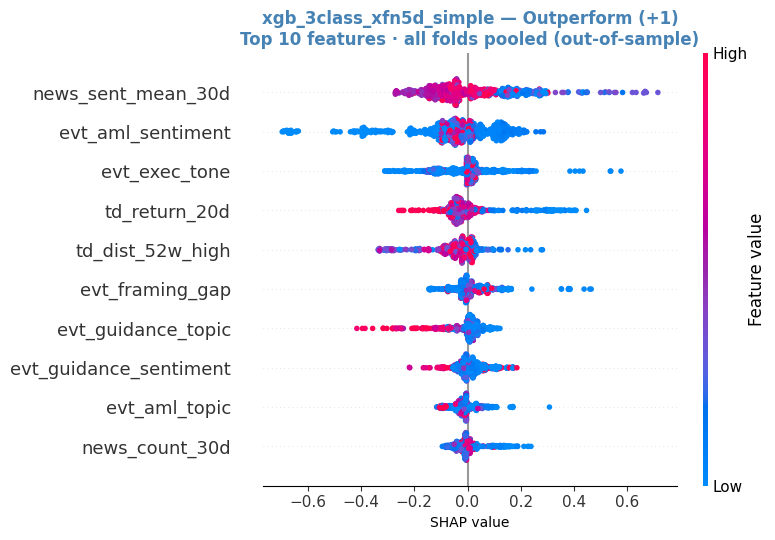

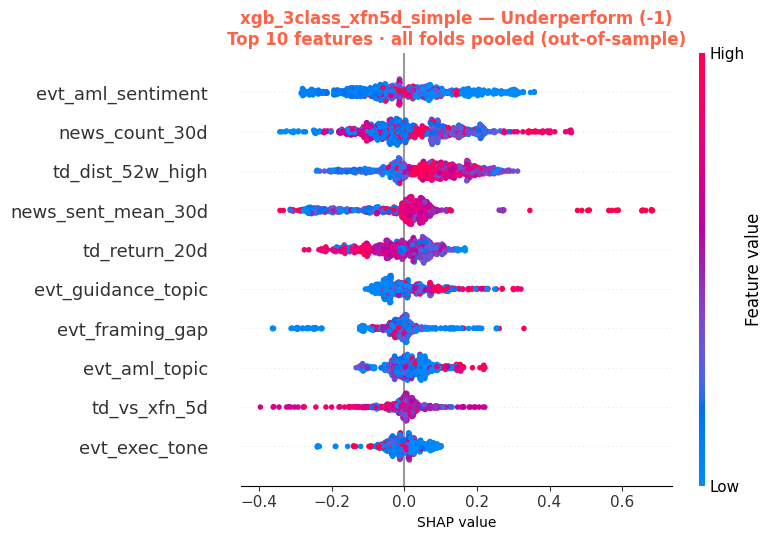

Top-10 Outperform (mean |SHAP|):
news_sent_mean_30d        0.121565
evt_aml_sentiment         0.116587
evt_exec_tone             0.065944
td_return_20d             0.060057
td_dist_52w_high          0.052800
evt_framing_gap           0.048016
evt_guidance_topic        0.040321
evt_guidance_sentiment    0.034583
evt_aml_topic             0.033797
news_count_30d            0.031762

Top-10 Underperform (mean |SHAP|):
evt_aml_sentiment     0.110197
news_count_30d        0.100402
td_dist_52w_high      0.099890
news_sent_mean_30d    0.088439
td_return_20d         0.068405
evt_guidance_topic    0.052121
evt_framing_gap       0.049696
evt_aml_topic         0.045506
td_vs_xfn_5d          0.036515
evt_exec_tone         0.033642


In [7]:
TOP_GLOBAL = 10

df_shap_out   = pd.DataFrame(fold_shap_out_dfs)
df_shap_under = pd.DataFrame(fold_shap_under_dfs)
imp_out   = df_shap_out.mean().sort_values(ascending=False)
imp_under = df_shap_under.mean().sort_values(ascending=False)

all_sv_out   = np.vstack(fold_sv_out_list)
all_sv_under = np.vstack(fold_sv_under_list)
all_x_te     = pd.concat(fold_x_te_list, ignore_index=True)

for sv_all, imp_cls, label, color in [
    (all_sv_out,   imp_out,   'Outperform (+1)',   'steelblue'),
    (all_sv_under, imp_under, 'Underperform (-1)', 'tomato'),
]:
    top_feats = imp_cls.head(TOP_GLOBAL).index.tolist()
    top_idx   = [features.index(f) for f in top_feats]
    sv_slice  = sv_all[:, top_idx]
    x_slice   = all_x_te[top_feats]

    plt.figure(figsize=(13, 7))
    shap.summary_plot(
        sv_slice, x_slice,
        feature_names=top_feats,
        plot_type='dot',
        max_display=TOP_GLOBAL,
        show=False,
        color_bar=True,
    )
    plt.title(
        f'xgb_3class_xfn5d_simple — {label}\n'
        f'Top {TOP_GLOBAL} features · all folds pooled (out-of-sample)',
        fontsize=12, fontweight='bold', color=color,
    )
    plt.xlabel('SHAP value', fontsize=10)
    plt.tight_layout()
    plt.show()

print('Top-10 Outperform (mean |SHAP|):')
print(imp_out.head(10).to_string())
print('\nTop-10 Underperform (mean |SHAP|):')
print(imp_under.head(10).to_string())

## 6. SHAP Stability Across Folds (Heatmap)

Top-10 features per class, showing how importance shifts fold-by-fold.

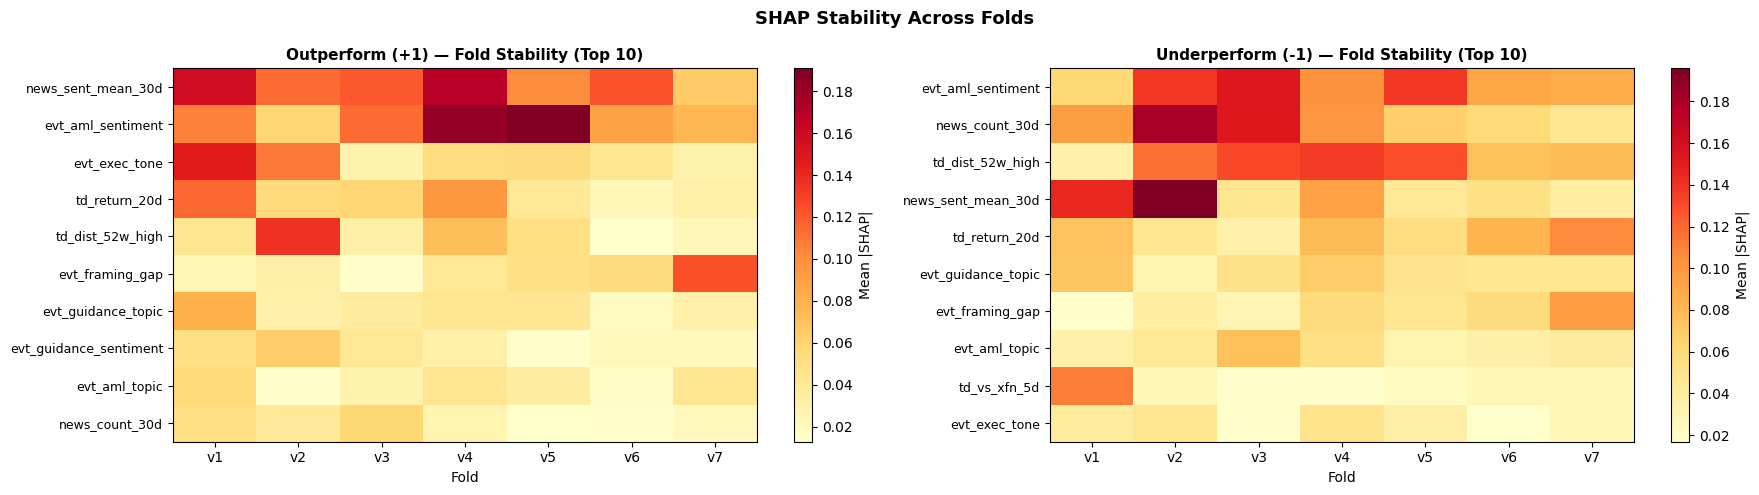

In [8]:
TOP_HEAT = 10

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, df_cls, imp_cls, label in [
    (axes[0], df_shap_out,   imp_out,   'Outperform (+1)'),
    (axes[1], df_shap_under, imp_under, 'Underperform (-1)'),
]:
    top  = imp_cls.head(TOP_HEAT).index.tolist()
    heat = df_cls[top].T

    im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f'v{i+1}' for i in range(len(heat.columns))], fontsize=10)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top, fontsize=9)
    ax.set_xlabel('Fold')
    ax.set_title(f'{label} — Fold Stability (Top {TOP_HEAT})', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Mean |SHAP|')

plt.suptitle('SHAP Stability Across Folds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Per-Fold Beeswarm — Top-5 Features (Outperform & Underperform)

For each fold: the 5 features with highest mean |SHAP| for that class in that fold.
Each dot = one test-set observation; colour encodes feature value (blue=low, red=high).

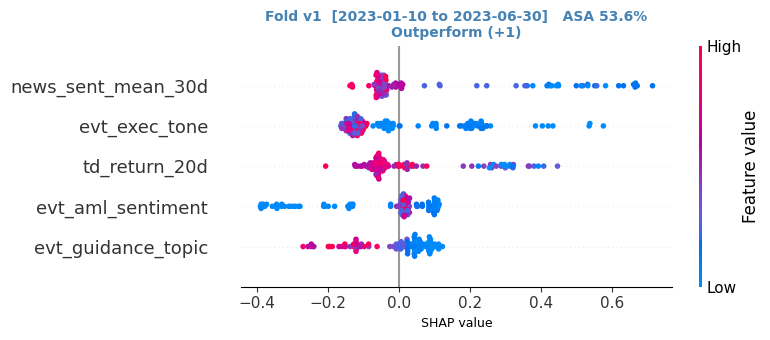

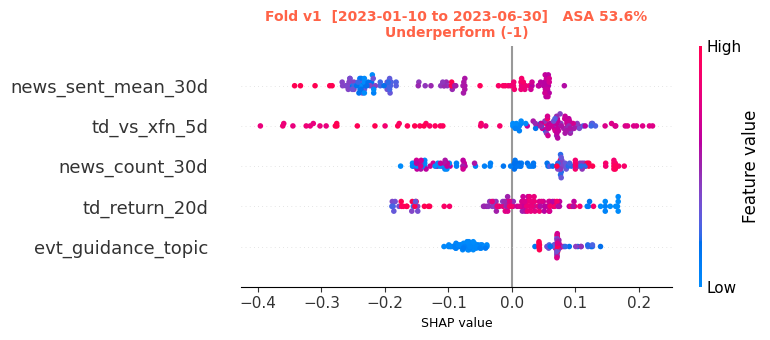

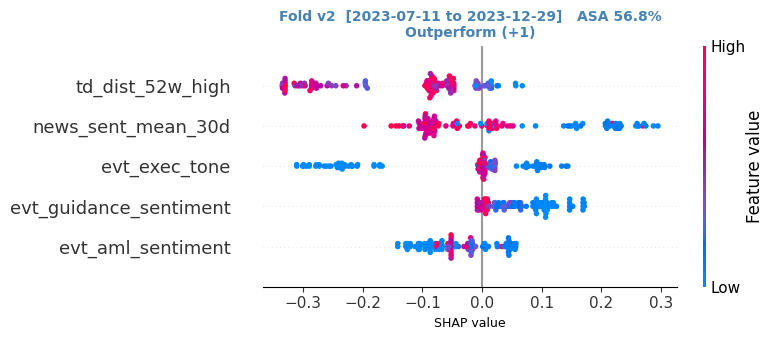

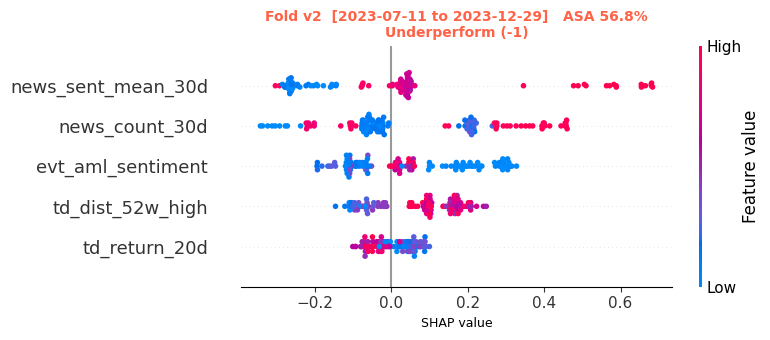

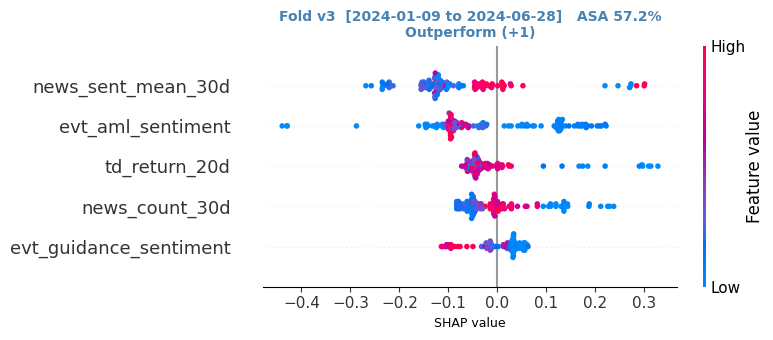

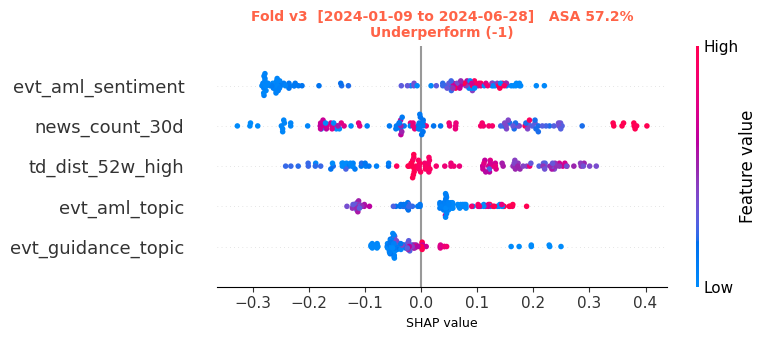

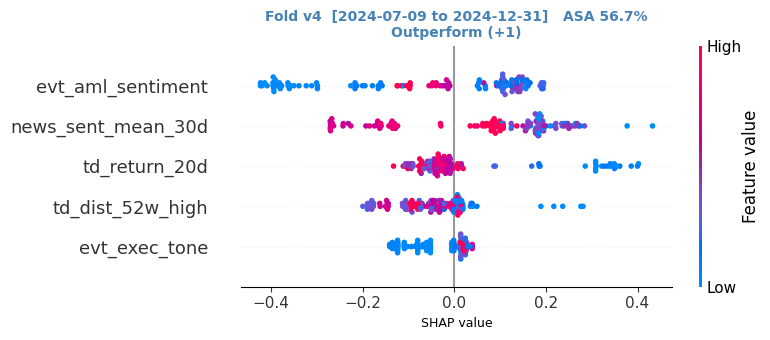

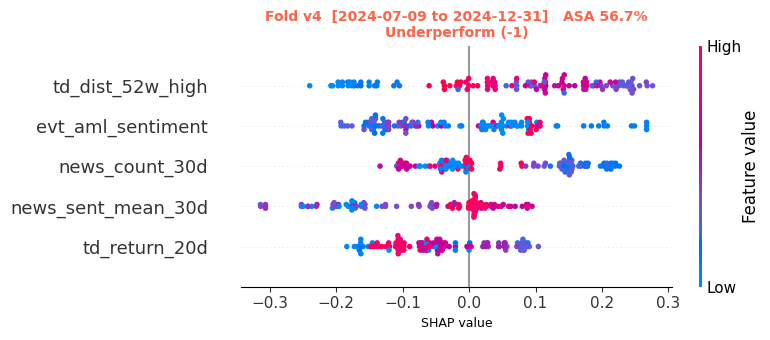

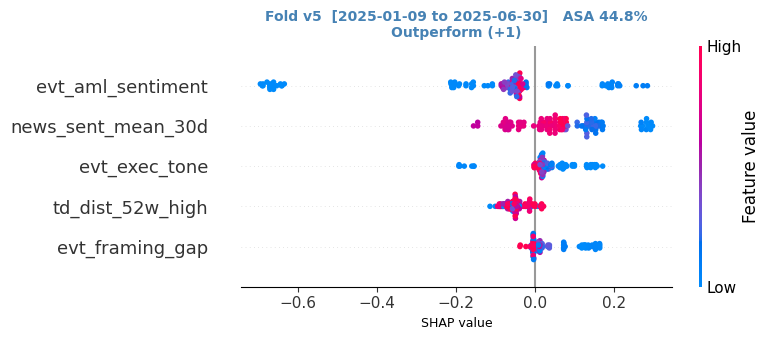

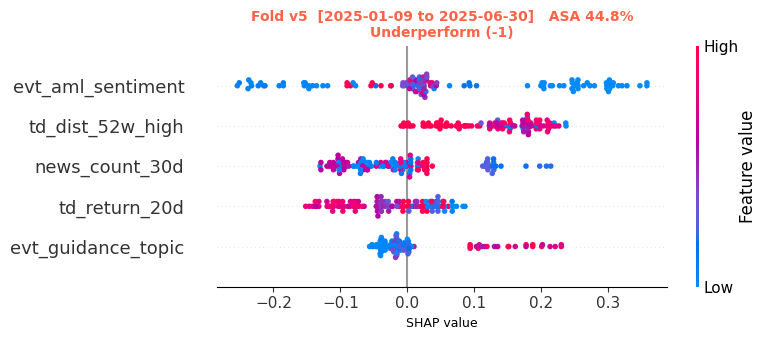

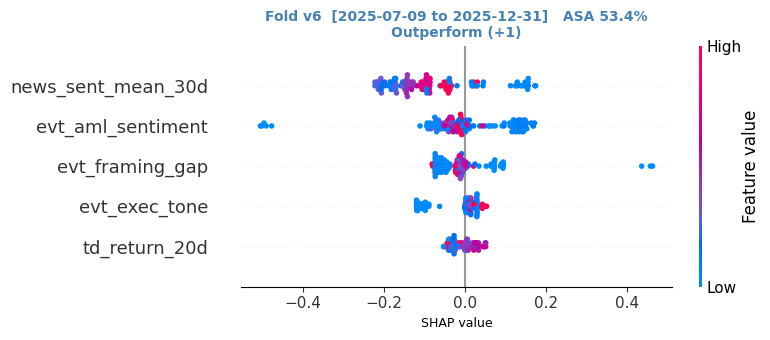

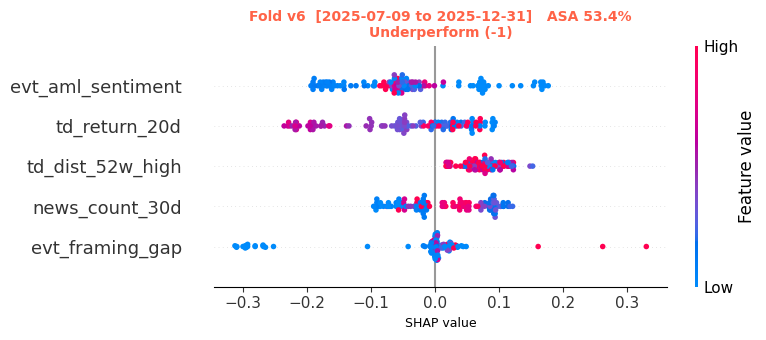

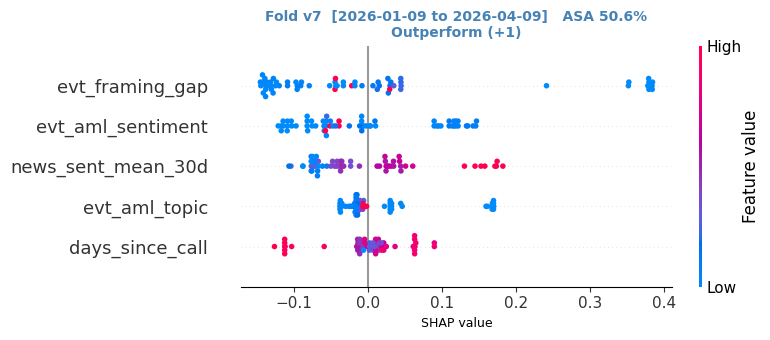

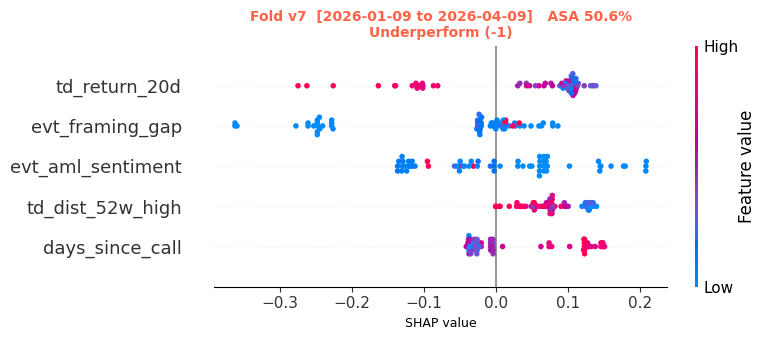

In [9]:
TOP_N = 5

for fold_idx, (fold_id, train_end, test_start, test_end) in enumerate(E10_FOLDS):
    x_te     = fold_x_te_list[fold_idx]
    sv_out   = fold_sv_out_list[fold_idx]
    sv_under = fold_sv_under_list[fold_idx]

    top5_out   = df_shap_out.iloc[fold_idx].sort_values(ascending=False).head(TOP_N).index.tolist()
    top5_under = df_shap_under.iloc[fold_idx].sort_values(ascending=False).head(TOP_N).index.tolist()
    asa_val    = results_df.loc[fold_id, 'active_asa']
    fold_hdr   = f'Fold {fold_id}  [{test_start} to {test_end}]   ASA {asa_val:.1%}'

    for sv_cls, top5, label, color in [
        (sv_out,   top5_out,   'Outperform (+1)',   'steelblue'),
        (sv_under, top5_under, 'Underperform (-1)', 'tomato'),
    ]:
        top_idx  = [features.index(f) for f in top5]
        sv_slice = sv_cls[:, top_idx]
        x_slice  = x_te[top5]

        plt.figure(figsize=(13, 4.5))
        shap.summary_plot(
            sv_slice, x_slice,
            feature_names=top5,
            plot_type='dot',
            max_display=TOP_N,
            show=False,
            color_bar=True,
        )
        plt.title(f'{fold_hdr}\n{label}', fontsize=10, fontweight='bold', color=color)
        plt.xlabel('SHAP value', fontsize=9)
        plt.tight_layout()
        plt.show()

## 8. XGBoost vs LightGBM — Same 15 Features, Same 7 Folds

Both models are re-fit per fold on the training window only (no look-ahead).  
LightGBM uses `best_params` from the most recent `lgbm_3class_xfn5d_simple_tuned-*.pkl` artifact.

In [10]:
import lightgbm as lgb

lgb_pkls = sorted(ARTIFACT_DIR.glob('lgbm_3class_xfn5d_simple_tuned-*.pkl'))
assert lgb_pkls, 'Run lgbm_3class_xfn5d_simple_training.ipynb first.'
with open(lgb_pkls[-1], 'rb') as f:
    lgb_art = pickle.load(f)
LGB_PARAMS = lgb_art['best_params']

print(f'XGB best params : {BEST_PARAMS}')
print(f'LGB best params : {LGB_PARAMS}')


def eval_fold_learner(train_df, test_df, learner):
    x_tr  = train_df[features].fillna(train_df[features].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([label_map[v] for v in y_tr], dtype=int)
    x_te  = test_df[features].fillna(train_df[features].median())

    if learner == 'xgb':
        clf = xgb.XGBClassifier(
            objective='multi:softprob', num_class=3,
            random_state=42, n_jobs=1, verbosity=0,
            **BEST_PARAMS,
        )
        clf.fit(x_tr, y_enc)
        preds_enc = clf.predict(x_te)
        preds = np.array([inv_map[int(p)] for p in preds_enc])
    else:
        clf = lgb.LGBMClassifier(
            objective='multiclass', num_class=3,
            random_state=42, verbose=-1, n_jobs=1,
            **LGB_PARAMS,
        )
        clf.fit(x_tr, y_enc)
        preds_enc = clf.predict(x_te)
        preds = np.array([inv_map[p] for p in preds_enc])

    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    return preds, y_te_cls, y_te_cont


xgb_rows, lgb_rows = [], []
for fold_id, train_end, test_start, test_end in E10_FOLDS:
    tr = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    te = ((df['date'] >= pd.Timestamp(test_start)) &
          (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
    train_df, test_df = df[tr], df[te]
    dates = test_df['date'].values

    px, yx, cx = eval_fold_learner(train_df, test_df, 'xgb')
    pl, yl, cl = eval_fold_learner(train_df, test_df, 'lgb')

    mx = offset_metrics(px, yx, cx, dates)
    ml = offset_metrics(pl, yl, cl, dates)

    xgb_rows.append({'fold': fold_id, **mx.to_dict()})
    lgb_rows.append({'fold': fold_id, **ml.to_dict()})

xgb_wf = pd.DataFrame(xgb_rows).set_index('fold')
lgb_wf = pd.DataFrame(lgb_rows).set_index('fold')

cols = ['mean_acc', 'macro_f1', 'active_cov', 'active_asa', 'dir_auc']
print('=== Per-Fold — XGBoost ===')
display(xgb_wf[cols].round(3))
print('\n=== Per-Fold — LightGBM ===')
display(lgb_wf[cols].round(3))

agg = pd.DataFrame({'xgb_15f': xgb_wf[cols].mean(), 'lgbm_15f': lgb_wf[cols].mean()})
agg['delta (xgb - lgbm)'] = agg['xgb_15f'] - agg['lgbm_15f']

print('\n=== 7-Fold Average — XGB vs LGBM (same 15 features & folds) ===')
display(agg.round(4))

xc = 0.6 * agg.loc['active_asa', 'xgb_15f']  + 0.4 * agg.loc['macro_f1', 'xgb_15f']
lc = 0.6 * agg.loc['active_asa', 'lgbm_15f'] + 0.4 * agg.loc['macro_f1', 'lgbm_15f']
print(f'\nComposite (0.6xASA + 0.4xF1):  XGB={xc:.4f}   LGBM={lc:.4f}   Delta={xc-lc:+.4f}')
print('\nNote: XGB and LGBM use identical folds, feature engineering, and stride-5 offset averaging.')

XGB best params : {'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'tree_method': 'hist', 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 80}
LGB best params : {'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'num_leaves': 4, 'min_child_samples': 40, 'n_estimators': 200}


=== Per-Fold — XGBoost ===


,mean_acc,macro_f1,active_cov,active_asa,dir_auc
fold,,,,,
v1,0.371,0.284,0.926,0.536,NaN
v2,0.454,0.336,0.992,0.568,NaN
v3,0.455,0.337,0.984,0.572,NaN
v4,0.471,0.355,0.959,0.567,NaN
v5,0.358,0.245,0.983,0.448,NaN
v6,0.414,0.334,0.992,0.534,NaN
v7,0.383,0.280,1.000,0.506,NaN



=== Per-Fold — LightGBM ===


,mean_acc,macro_f1,active_cov,active_asa,dir_auc
fold,,,,,
v1,0.313,0.244,0.843,0.517,NaN
v2,0.411,0.319,0.932,0.576,NaN
v3,0.555,0.421,0.975,0.679,NaN
v4,0.487,0.362,0.975,0.559,NaN
v5,0.325,0.263,0.892,0.412,NaN
v6,0.405,0.368,0.918,0.550,NaN
v7,0.399,0.296,0.985,0.500,NaN



=== 7-Fold Average — XGB vs LGBM (same 15 features & folds) ===


,xgb_15f,lgbm_15f,delta (xgb - lgbm)
mean_acc,0.4152,0.4136,0.0016
macro_f1,0.3099,0.3246,-0.0147
active_cov,0.9764,0.9314,0.0450
active_asa,0.5330,0.5419,-0.0089
dir_auc,NaN,NaN,NaN



Composite (0.6xASA + 0.4xF1):  XGB=0.4438   LGBM=0.4550   Delta=-0.0112

Note: XGB and LGBM use identical folds, feature engineering, and stride-5 offset averaging.


## 9. Feature List

All 15 features grouped by block for reproducibility.

In [11]:
feature_groups = {
    'Price & Relative Momentum': [
        'td_return_5d', 'td_return_20d', 'td_vs_xfn_5d', 'td_dist_52w_high',
    ],
    'News Flow': [
        'news_sent_mean_30d', 'news_count_30d', 'days_since_last_news',
    ],
    'Timing': [
        'days_since_call', 'is_earnings_week',
    ],
    'NLP Event (call_decay * raw or combined)': [
        'evt_exec_tone', 'evt_framing_gap',
        'evt_guidance_topic', 'evt_guidance_sentiment',
        'evt_aml_topic', 'evt_aml_sentiment',
    ],
}

all_listed = sum(feature_groups.values(), [])
assert sorted(all_listed) == sorted(features), 'Feature group mismatch!'

for group, feats in feature_groups.items():
    print(f'\n{group} ({len(feats)} features):')
    for f in feats:
        print(f'  - {f}')

print(f'\nTotal: {len(features)} features')


Price & Relative Momentum (4 features):
  - td_return_5d
  - td_return_20d
  - td_vs_xfn_5d
  - td_dist_52w_high

News Flow (3 features):
  - news_sent_mean_30d
  - news_count_30d
  - days_since_last_news

Timing (2 features):
  - days_since_call
  - is_earnings_week

NLP Event (call_decay * raw or combined) (6 features):
  - evt_exec_tone
  - evt_framing_gap
  - evt_guidance_topic
  - evt_guidance_sentiment
  - evt_aml_topic
  - evt_aml_sentiment

Total: 15 features
